# Discrete Fourier Transform

cos coef= [[ 1.01701946e+00  5.00862259e+00 -3.67670634e-03  1.97954362e-03
   9.98273527e-01 -7.70304371e-03  3.02604443e-03 -1.01265354e-02
  -4.09847956e-03 -1.12679814e-02  2.92960648e-02  2.38226055e-03
   7.74895524e-03  9.45074036e-04  2.72069682e-03  2.12679362e-03
  -1.48075405e-03  5.84136014e-03 -6.84873199e-03  2.66286455e-03
  -4.49835486e-03  9.04364695e-03  2.10490968e-03 -1.67387044e-03
  -3.19816986e-03  4.61300928e-03 -5.59060901e-03  1.42254847e-03
  -8.70227138e-03 -1.30130940e-02 -1.21011078e-03 -5.66236188e-03
   3.18821374e-03  3.83876388e-03  6.09932810e-04  4.20461105e-03
   8.73248234e-03  1.87828286e-03 -4.85459662e-03  1.10113536e-02
   2.01209596e-03 -5.13464914e-04  2.97908298e-03 -5.54974914e-03
   2.81015218e-03  9.47961606e-05 -9.52241623e-03 -4.32868995e-03
  -4.74924849e-03 -2.96155795e-03 -1.19296922e-03 -3.30683769e-03
  -3.41275959e-03  9.65211812e-04 -3.40020513e-04  7.23049843e-06
   8.34950208e-04 -6.31659825e-03 -6.24924538e-03 -1.96686690e-03


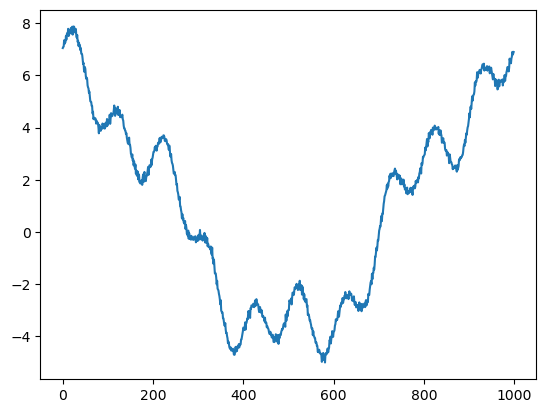

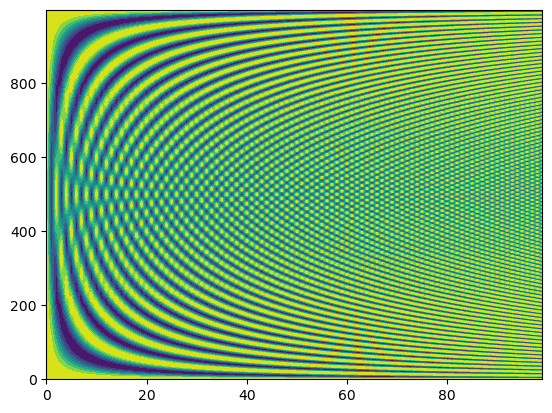

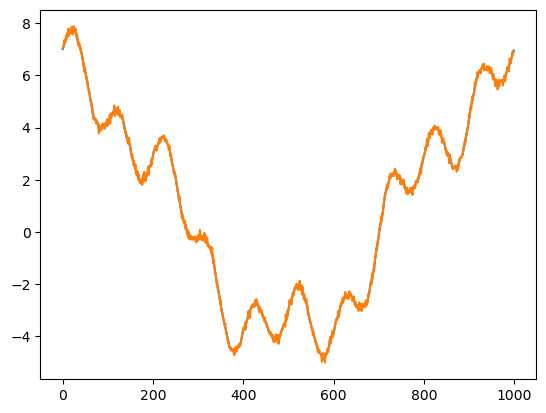

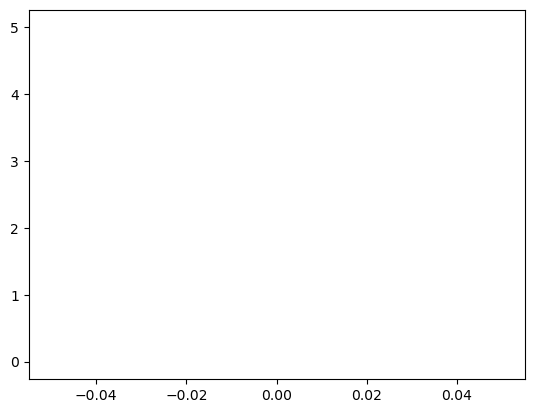

In [29]:
import numpy as np
from matplotlib import pyplot as plt

def fourier(y, number_of_harmonics):
    x             = np.matrix(np.arange(0,np.size(y)))/np.size(y)*2*3.14159
    #
    #print(x)
    n             = np.matrix(np.arange(0,number_of_harmonics))
    omega         = x.T.dot(n)
    cos_coef      = np.matrix(y).dot(np.cos(omega))
    sin_coef      = np.matrix(y).dot(np.sin(omega))
    cos_coef      = cos_coef/np.size(y)*2
    sin_coef      = sin_coef/np.size(y)*2
    cos_coef[0,0] = cos_coef[0,0]/2
    reconstruct   = cos_coef.dot(np.cos(omega).T)+sin_coef.dot(np.sin(omega).T)
    return cos_coef,sin_coef, reconstruct, omega

x = np.linspace(0,2*3.14159,1000)
y = 1*np.cos(0*x)+5*np.cos(x)+np.cos(4*x)+np.sin(10*x)+np.random.normal(0,0.1,1000)
plt.plot(y)

wave_number                   = 100
cos_coef,sin_coef,reconstruct, omega = fourier(y,wave_number)
plt.figure()
plt.contourf(np.cos(omega))
# plt.scatter(np.arange(0,wave_number),np.array(cos_coef),s=40)
# plt.scatter(np.arange(0,wave_number),np.array(sin_coef),s=40)
plt.figure()
plt.plot(reconstruct[0,:].T)
plt.plot(y)

print('cos coef=',cos_coef)
print('sin coef=',sin_coef)
plt.figure()
plt.plot(cos_coef)

[[14.5900508+0.j]]
13.55572221601041


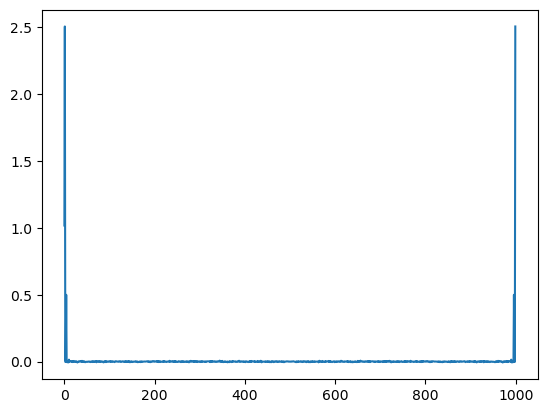

In [30]:
def dft(y):
    y = np.asarray(y, dtype=float)
    N = y.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, y)/np.size(y)

plt.plot(dft(y))
y_hat = np.matrix(dft(y))
print(y_hat.dot((y_hat.conjugate()).T))
print(np.var(y))

# Gibbs phenomenon

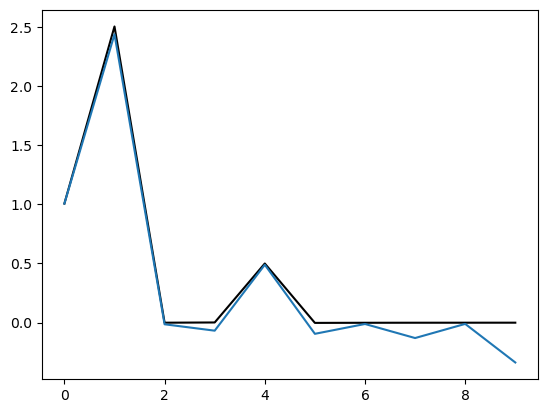

In [ ]:
y        = np.cos(0*x)+5*np.cos(x)+np.cos(4*x)+np.sin(10*x)
plt.plot(dft(y)[0:10],'k')
# maskout the data by half
y[0:500] = 0
plt.plot(dft(y)[0:10]*2)




## Fast Fourier Transform

In [ ]:
import numpy as np

def fft(x):
    N = len(x)
    if N <= 1:
        return x
    even = fft(x[0::2])
    odd  = fft(x[1::2])
    T = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]
    return [even[k] + T[k] for k in range(N // 2)] + \
           [even[k] - T[k] for k in range(N // 2)]

def fft_recursive(x):
    N = len(x)
    if N % 2 > 0:
        raise ValueError("Length of input must be a power of 2")
    elif N <= 32:
        return fft(x)
    else:
        even = fft_recursive(x[0::2])
        odd = fft_recursive(x[1::2])
        T = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]
        return [even[k] + T[k] for k in range(N // 2)] + \
               [even[k] - T[k] for k in range(N // 2)]

def main():
    x = np.random.random(1024)
    #print("Input sequence:", x)
    y = fft_recursive(x)
    #print("FFT result:", y)

if __name__ == "__main__":
    main()

In [ ]:
def FFT(x):
    """
    A recursive implementation of
    the 1D Cooley-Tukey FFT, the
    input should have a length of
    power of 2.
    """
    N = len(x)

    if N == 1:
        return x
    else:
        X_even = FFT(x[::2])
        X_odd  = FFT(x[1::2])
        factor = np.exp(-2j*np.pi*np.arange(N)/ N)

        X = np.concatenate(\
            [X_even+factor[:int(N/2)]*X_odd,
             X_even+factor[int(N/2):]*X_odd])
        return X

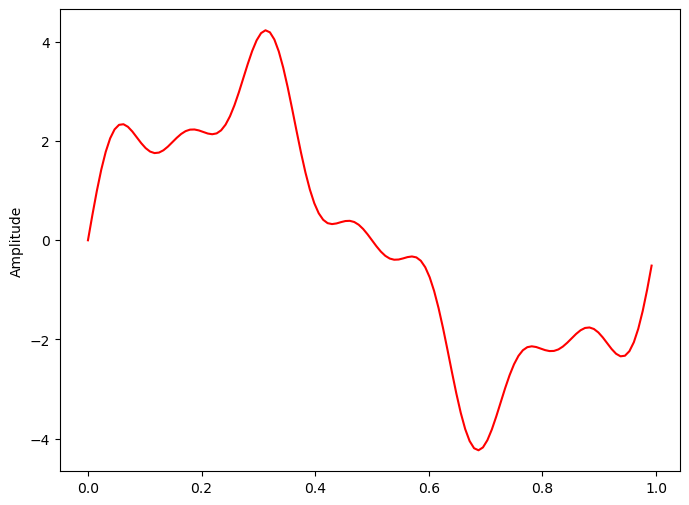

In [ ]:
# sampling rate
sr = 128
# sampling interval
ts = 1.0/sr
t  = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

638 µs ± 10.4 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
258 µs ± 962 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


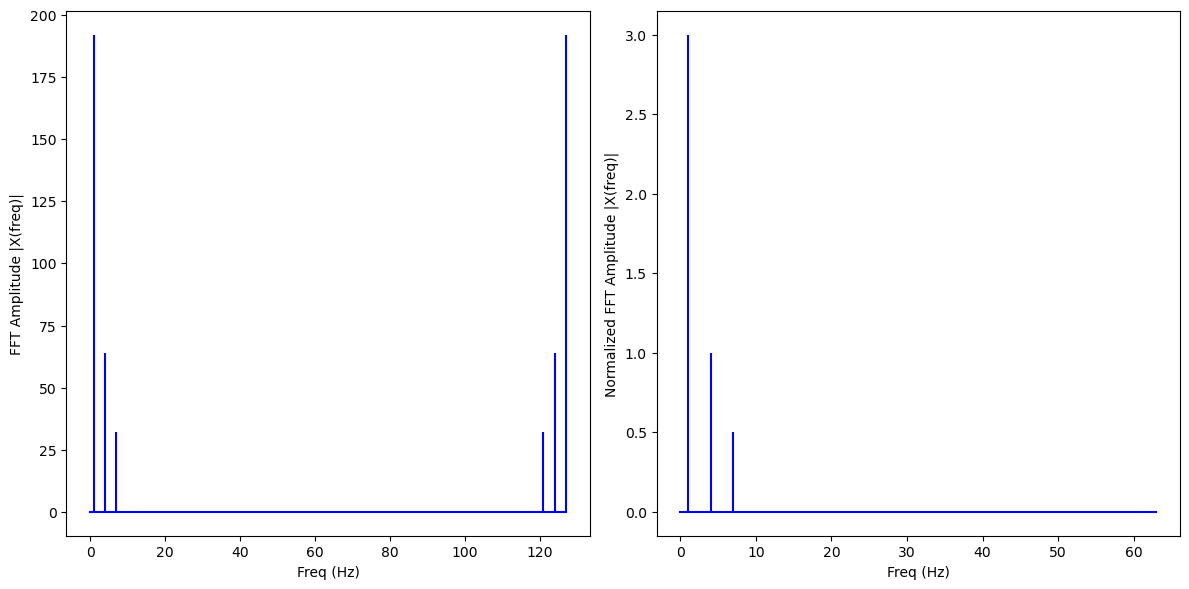

In [ ]:
%timeit X=FFT(x)
%timeit dft(x)
# calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.stem(freq, abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

# normalize the amplitude
X_oneside =X[:n_oneside]/n_oneside

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('Normalized FFT Amplitude |X(freq)|')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def fft(x):
    N = len(x)
    if N <= 1:
        return x
    even = fft(x[::2])
    odd = fft(x[1::2])
    T = [np.exp(-2j * np.pi * k / N) * odd[k] for k in range(N // 2)]
    return [even[k] + T[k] for k in range(N // 2)] + \
           [even[k] - T[k] for k in range(N // 2)]


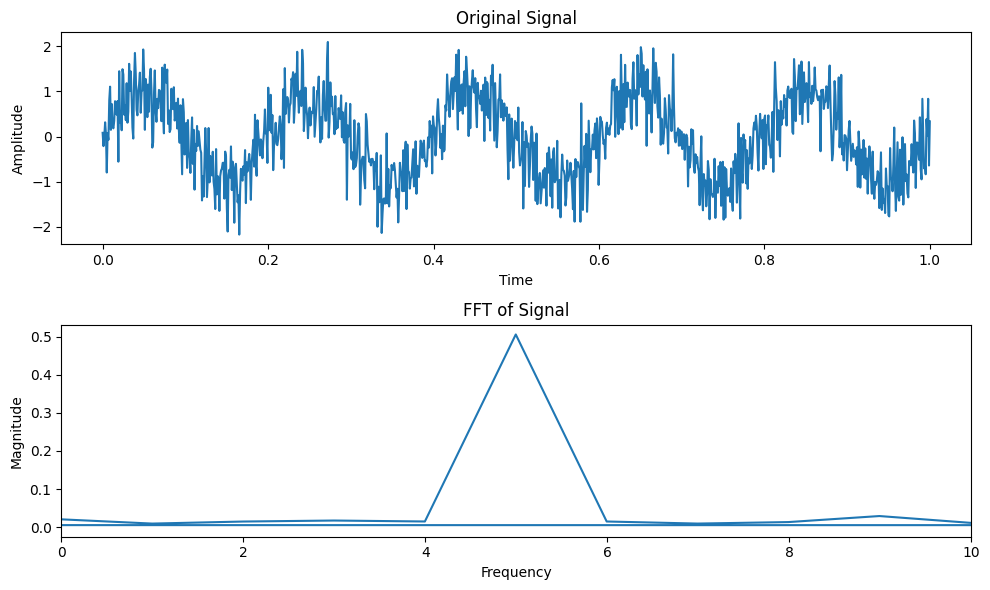

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a sinusoidal signal with noise
t = np.linspace(0, 1, 1000)
f_signal = 5  # Frequency of the signal
signal = np.sin(2 * np.pi * f_signal * t) + 0.5 * np.random.randn(1000)  # Adding noise

# Compute FFT
fft_result = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(signal), t[1] - t[0])

# Plot the original signal
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title('Original Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Plot the FFT result (scaled properly)
plt.subplot(2, 1, 2)
plt.plot(frequencies, np.abs(fft_result) / len(signal))  # Normalize FFT by the length of the signal
plt.title('FFT of Signal')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.xlim(0, 10)  # Limiting x-axis to frequencies up to 10 Hz for clarity
plt.tight_layout()
plt.show()

